In [1]:
import os
import pandas as pd
import joblib

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from scipy.sparse import load_npz
from sklearn.metrics import classification_report, f1_score, roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

In [2]:
DATA_PR = "../data/processed/"

## Chuẩn bị Dataset

In [3]:
X = load_npz(DATA_PR + "train_X.npz")
y = pd.read_csv(DATA_PR + "train_y.csv")

print(X.shape)
print(y.shape)

(140700, 76)
(140700, 1)


In [4]:
df_names = pd.read_csv(DATA_PR + "train_feature_names.csv")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

feature_pipeline = joblib.load("../artifacts/feature_pipeline.joblib")

## Training, Evaluating Model

### Lựa chọn độ đo
**1. Accuracy**

Mặc dù **Accuracy** (Độ chính xác tổng thể) là chỉ số phổ biến nhất, nhưng nó thường gây hiểu lầm trong các tập dữ liệu **mất cân bằng (Imbalanced Data)**. 

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

Trong tập dữ liệu này, số lượng người không mắc bệnh (Lớp 0) chiếm đa số. Nếu mô hình dự đoán tất cả mọi người đều "Không bệnh", Accuracy vẫn sẽ rất cao nhưng mô hình đó hoàn toàn vô dụng vì không phát hiện được bất kỳ bệnh nhân nào.

---

**2. Recall**

Trong bối cảnh y tế và tâm lý học, chúng ta đối mặt với hai loại sai lầm:

1.  **Sai lầm loại I (False Positive - Dương tính giả):** Chẩn đoán nhầm một người bình thường là có bệnh.
    * *Hậu quả:* Người đó cần thực hiện thêm các bài kiểm tra hoặc tư vấn chuyên sâu hơn. Chi phí này có thể chấp nhận được.
2.  **Sai lầm loại II (False Negative - Âm tính giả):** Bỏ sót một người thực sự đang gặp vấn đề về sức khỏe tâm thần.
    * *Hậu quả:* Đây là sai lầm **nguy hiểm**. Người bệnh không được can thiệp kịp thời, có thể dẫn đến những hệ lụy nghiêm trọng về sức khỏe và tính mạng.

Vì vậy, mục tiêu bài toán là tối ưu hóa chỉ số **Recall**:

$$Recall = \frac{TP}{TP + FN}$$

In [5]:
def print_evaluate(y_val, y_pred, y_proba):
    print(f"Accuracy:, {accuracy_score(y_val, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_val, y_proba):.4f}")
    print(f"F1-score: {f1_score(y_val, y_pred):.4f}")
    print("\nClassification Report:\n", classification_report(y_val, y_pred))

In [6]:
def print_cfm(y_val, y_pred):
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix for XGBoost")
    plt.show()

### XGBoost Model

In [7]:
model_xgb = xgb.XGBClassifier(
    n_estimators=100,   # Số lượng vòng lặp
    learning_rate=0.1,  # Tốc độ học
    max_depth=6,        # Độ sâu tối đa của cây
    random_state=42,
    eval_metric='logloss'
)

# Huấn luyện
model_xgb.fit(X_train, y_train)

# Dự đoán
y_pred_xgb = model_xgb.predict(X_val)
y_proba_xgb = model_xgb.predict_proba(X_val)[:, 1]

# Evaluating
print_evaluate(y_val, y_pred_xgb, y_proba_xgb)

Accuracy:, 0.9380
ROC-AUC: 0.9740
F1-score: 0.8267

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96     23027
           1       0.84      0.81      0.83      5113

    accuracy                           0.94     28140
   macro avg       0.90      0.89      0.89     28140
weighted avg       0.94      0.94      0.94     28140



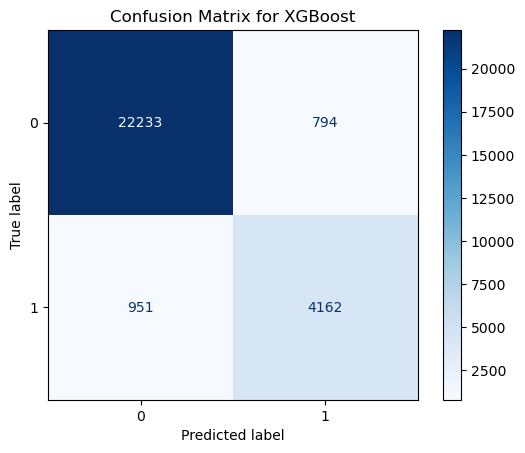

In [8]:
print_cfm(y_val, y_pred_xgb)

In [9]:
joblib.dump(model_xgb, "../artifacts/model_xgb.joblib")
print("Save XGBoost Model")

Save XGBoost Model


In [10]:
feature_names = df_names['feature_name'].tolist() # Chuyển dữ liệu feature_names thành list

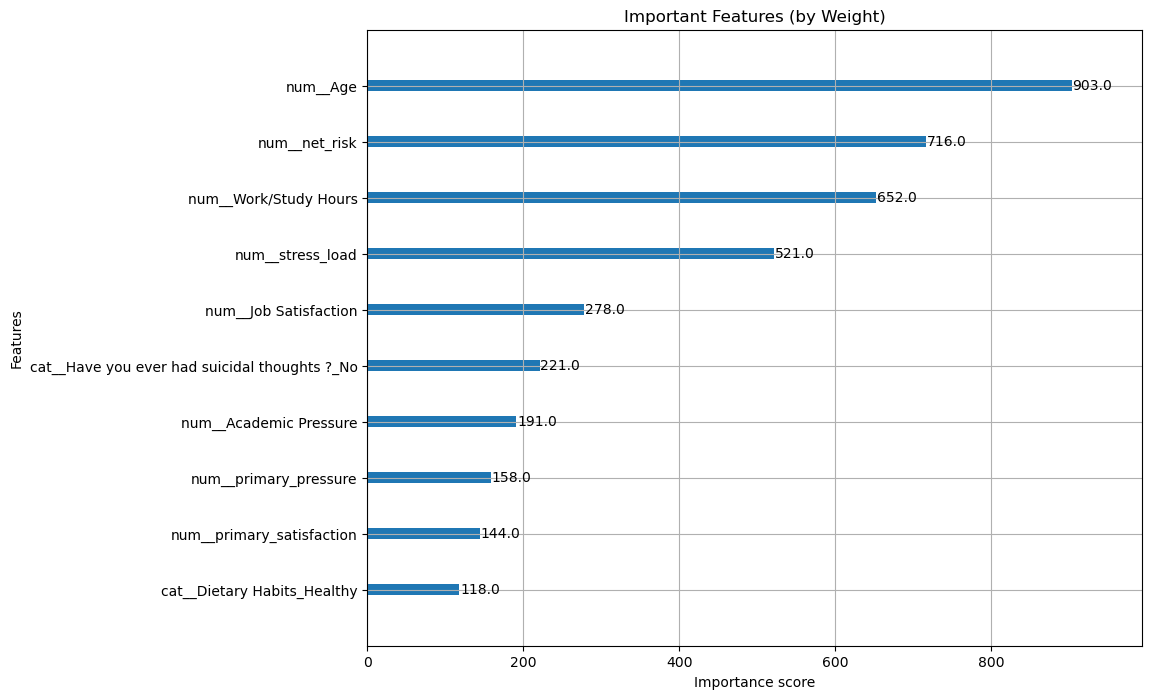

In [11]:
# Các Feature quan trọng ảnh hưởng đến kết quả Model
model_xgb.get_booster().feature_names = list(feature_names)

fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(model_xgb, max_num_features=10, ax=ax, importance_type='weight')
plt.title("Important Features (by Weight)")
plt.show()

### XGBoost Model + `scale_pos_weight`

In [ ]:
model_xgb_scale = xgb.XGBClassifier(
    n_estimators=100,   # Số lượng vòng lặp
    learning_rate=0.1,  # Tốc độ học
    max_depth=6,        # Độ sâu tối đa của cây
    random_state=42,
    scale_pos_weight = 4,   # Do tỉ lệ class 0 và 1 là 4 : 1 -> scale 1 lên 4
    eval_metric='logloss'
)

# Train model
model_xgb_scale.fit(X_train, y_train)

# Dự đoán kết quả tập Validation
y_pred_xgb_scale = model_xgb_scale.predict(X_val)
y_proba_xgb_scale = model_xgb_scale.predict_proba(X_val)[:, 1]

# Evaluating
print_evaluate(y_val, y_pred_xgb_scale, y_proba_xgb_scale)

Accuracy:, 0.9217
ROC-AUC: 0.9740
F1-score: 0.8099

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95     23027
           1       0.72      0.92      0.81      5113

    accuracy                           0.92     28140
   macro avg       0.85      0.92      0.88     28140
weighted avg       0.93      0.92      0.93     28140



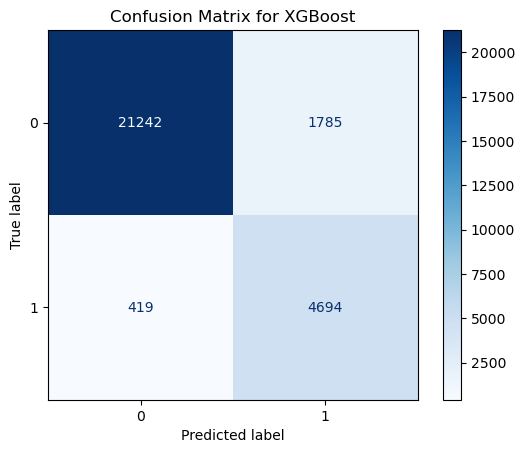

In [13]:
# Vẽ Confusion Matrix
print_cfm(y_val, y_pred_xgb_scale)

In [14]:
joblib.dump(model_xgb, "../artifacts/model_xgb_scale.joblib")
print("Save XGBoost Model with scale")

Save XGBoost Model with scale


### CatBoost Model + `scale_pos_weight`

In [15]:
model_cat = CatBoostClassifier(
    iterations=1000,            # Tương đương n_estimators
    learning_rate=0.05,
    depth=6,                    # Tương đương max_depth
    l2_leaf_reg=3,              # Tham số chính quy hóa (Regularization)
    loss_function='Logloss',
    eval_metric='AUC',          # Tối ưu hóa theo AUC
    random_seed=42,
    verbose=100,                # In kết quả sau mỗi 100 vòng lặp
    scale_pos_weight=4
)

# Huấn luyện model
model_cat.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

# Dự đoán
y_pred_cat = model_cat.predict(X_val)
y_proba_cat = model_cat.predict_proba(X_val)[:, 1]

print_evaluate(y_val, y_pred_cat, y_pred_cat)

0:	test: 0.9571534	best: 0.9571534 (0)	total: 119ms	remaining: 1m 59s
100:	test: 0.9736836	best: 0.9736836 (100)	total: 1.07s	remaining: 9.5s
200:	test: 0.9741329	best: 0.9741394 (192)	total: 2s	remaining: 7.97s
300:	test: 0.9743055	best: 0.9743075 (298)	total: 2.93s	remaining: 6.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9743074931
bestIteration = 298

Shrink model to first 299 iterations.
Accuracy:, 0.9210
ROC-AUC: 0.9207
F1-score: 0.8089

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95     23027
           1       0.72      0.92      0.81      5113

    accuracy                           0.92     28140
   macro avg       0.85      0.92      0.88     28140
weighted avg       0.93      0.92      0.92     28140



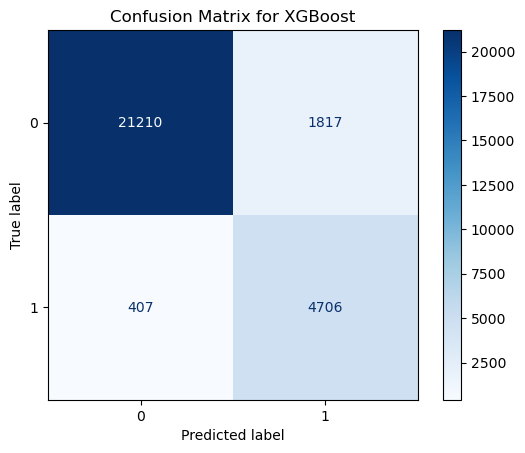

In [16]:
print_cfm(y_val, y_pred_cat)

In [17]:
joblib.dump(model_xgb, "../artifacts/model_cat.joblib")
print("Save CatBoost Model")

Save CatBoost Model


### Stacking Model (XGBoost + CatBoost)

In [18]:
# Base Models
base_models = [
    ('xgb', model_xgb),
    ('cat', model_cat),
]

# Định nghĩa Meta-model
meta_model = LogisticRegression()

# Tạo Stacking Classifier
stacking_model = StackingClassifier(
    estimators=base_models, 
    final_estimator=meta_model,
    cv=5, # Sử dụng Cross-validation
    stack_method='predict_proba'
)

stacking_model.fit(X_train, y_train)

d:\ProgramFiles\Anaconda\envs\min_ds-env\Lib\site-packages\sklearn\preprocessing\_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\ProgramFiles\Anaconda\envs\min_ds-env\Lib\site-packages\sklearn\preprocessing\_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


0:	total: 9.74ms	remaining: 9.73s
100:	total: 892ms	remaining: 7.94s
200:	total: 1.74s	remaining: 6.91s
300:	total: 2.58s	remaining: 5.99s
400:	total: 3.42s	remaining: 5.1s
500:	total: 4.25s	remaining: 4.23s
600:	total: 5.09s	remaining: 3.38s
700:	total: 5.94s	remaining: 2.53s
800:	total: 6.79s	remaining: 1.69s
900:	total: 7.64s	remaining: 839ms
999:	total: 8.48s	remaining: 0us
0:	total: 13.5ms	remaining: 13.5s
100:	total: 952ms	remaining: 8.47s
200:	total: 1.8s	remaining: 7.18s
300:	total: 2.7s	remaining: 6.26s
400:	total: 3.62s	remaining: 5.4s
500:	total: 4.47s	remaining: 4.45s
600:	total: 5.31s	remaining: 3.53s
700:	total: 6.17s	remaining: 2.63s
800:	total: 7.08s	remaining: 1.76s
900:	total: 7.96s	remaining: 874ms
999:	total: 8.86s	remaining: 0us
0:	total: 11.9ms	remaining: 11.9s
100:	total: 977ms	remaining: 8.7s
200:	total: 1.91s	remaining: 7.59s
300:	total: 2.81s	remaining: 6.53s
400:	total: 3.75s	remaining: 5.6s
500:	total: 4.72s	remaining: 4.7s
600:	total: 5.62s	remaining: 3.73s

StackingClassifier(cv=5,
                   estimators=[('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interac...
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('cat',
                                CatBoostClassifier(depth=6, eval_metric='AUC', iterations=1000, l2_leaf_reg=3, learning_rate=0.05, loss_function='Logloss', random_seed=42, scale_pos_weight=4, verbose=100))],
                   final_estimator=LogisticRegression(),
                   stack_method='predict_proba')

In [19]:
y_pred_stack = stacking_model.predict(X_val)
y_proba_stack = stacking_model.predict_proba(X_val)[:, 1]

print_evaluate(y_val, y_pred_stack, y_proba_stack)

Accuracy:, 0.9380
ROC-AUC: 0.9740
F1-score: 0.8311

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96     23027
           1       0.82      0.84      0.83      5113

    accuracy                           0.94     28140
   macro avg       0.89      0.90      0.90     28140
weighted avg       0.94      0.94      0.94     28140



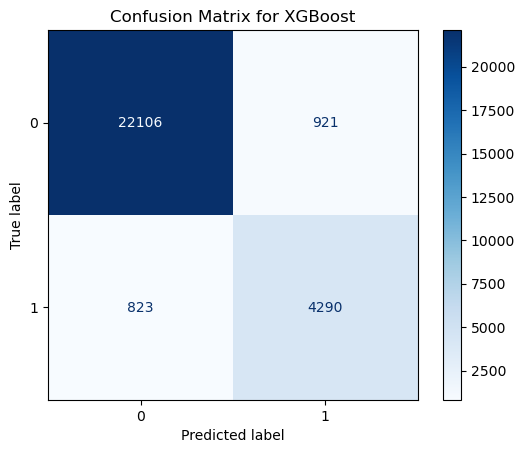

In [20]:
print_cfm(y_val, y_pred_stack)

In [21]:
joblib.dump(model_xgb, "../artifacts/model_stack.joblib")
print("Save Stacking Model")

Save Stacking Model


## Lựa chọn model
- Ưu tiên y tế: Chọn XGBoost Model + `scale_pos_weight` vì có Recall lớp 1 cao vượt trội (0.92), giúp tối ưu khả năng phát hiện bệnh và giảm thiểu tối đa rủi ro bỏ sót các trường hợp trầm cảm cần can thiệp.

- Ưu tiên cân bằng: Chọn Stacking Model nếu mục tiêu là sự cân bằng tối ưu giữa các chỉ số (Accuracy, Precision và F1-score), giúp giảm thiểu tỷ lệ báo động giả và tối ưu hóa nguồn lực kiểm định chuyên sâu.